In [1]:
import numpy as np
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
import scipy.signal
import pynapple as nap

import pandas as pd
import scipy.io as spio
import os
import tifffile
from totalsync_utils import decode_b64_files
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "figure.figsize": (8, 4)}
sns.set_context("paper")
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.3, rc=custom_params)



In [2]:
pin_sheet_file = '/docs/pinSheet_2026.json'
# Path_non_decoded_files = "/data/ofl_2p/A04_day2"
# Path_non_decoded_files = "/data/ofl_2p/A04_day3"
Path_non_decoded_files = "/data/ofl_2p/unity_scanner_totalsync"
# s3d_results_folder = "/Users/fpbattaglia/Dropbox/Data/ofl_2p/s3d-results-00003split_test-std"


In [3]:
tif_files = sorted(str(p) for p in Path(Path_non_decoded_files).glob("*.tif"))
print(tif_files)

['/data/ofl_2p/unity_scanner_totalsync/barcodetest_unity_scanner_totalsync_00001.tif']


In [4]:
tif = tifffile.TiffFile(tif_files[0])
len(tif.pages)

7015

In [5]:
del tif

In [6]:
def extract_barcode_from_tif(tif_file: str) -> dict:
    tag_structure = {'image_description': 5,
                 'frame_timestamp': 3,
                 'auxTrigger0': 10}  # position of aux tag in tif header

    aux_data = {'frame_n': [],'ts': [], 'value': [] }
    data_reads = []
    #reading the aux line from the tiff pages
    with tifffile.TiffFile(tif_file) as tif:
        n_pages = len(tif.pages)
        ts = np.zeros(n_pages)
        value = np.zeros(n_pages)
        frame_n = np.zeros(n_pages)
        for i, page in tqdm(enumerate(tif.pages)):

            # extract image description string
            description = page.tags.values()[tag_structure['image_description']].value
            timestamp = float(description.split('\n')[tag_structure['frame_timestamp']].split('=')[-1])  # fetch timestamp in image description
            aux_line = description.split('\n')[tag_structure['auxTrigger0']]
            data = aux_line.split('=')[-1].strip(' [').strip(']').strip(' ]')
            ts[i] = timestamp
            frame_n[i] = i
            if 0 < len(data) < 50:
                try:
                    val = float(data)
                    value[i] = val
                except ValueError:
                    pass
    aux_data['ts'] = ts
    aux_data['value'] = value
    aux_data['frame_n'] = frame_n
    return aux_data, data_reads


In [7]:
b64_files = sorted(Path(Path_non_decoded_files).glob("*.b64"))
b64_files = sorted(str(p) for p in Path(Path_non_decoded_files).glob("*.b64"))
tsync_file = b64_files[0]
tsync_session = Path(tsync_file).stem

results_pins = decode_b64_files(Path_non_decoded_files, pin_json_path=pin_sheet_file)

tsync_data = results_pins[tsync_session]


Processing 20260507-171019_550.b64...
/data/ofl_2p/unity_scanner_totalsync/20260507-171019_550.b64
260739 packets, ~4.35 minutes


100%|██████████| 260739/260739 [00:08<00:00, 32044.87it/s]


In [8]:

tsync_file = b64_files[0]
tsync_session = Path(tsync_file).stem
tsync_data_00001 = results_pins[tsync_session]

In [9]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) == 1)[0]+1 # on the rising edge of the TTL line

In [10]:
np.max(np.diff(log_times))
log_times[np.where(np.diff(log_times) > 120000)[0]]

array([1002190992])

In [11]:
log_times[-1]

np.int64(1011149992)

(1002.0, 1003.0)

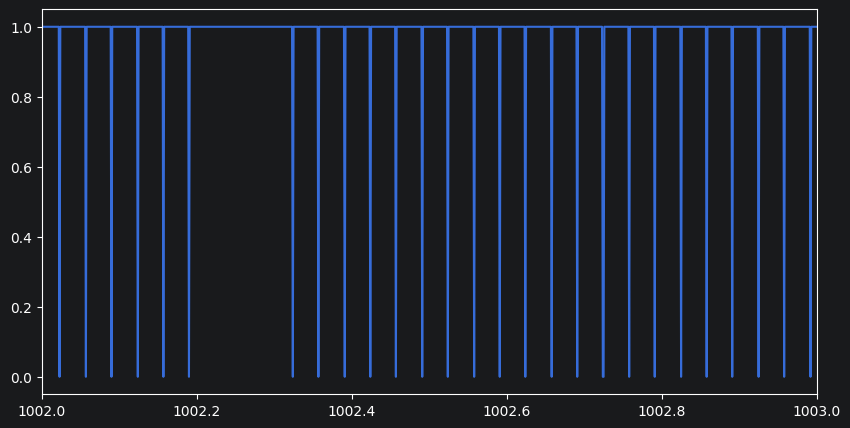

In [13]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(log_times/1e6, frame_clock)
ax.set_xlim(1002, 1003)

(0.0, 100000.0)

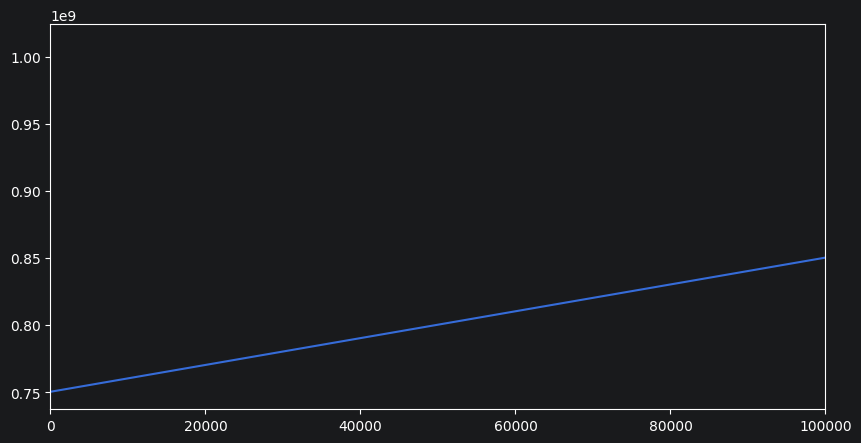

In [14]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(log_times)
ax.set_xlim(0, 100000)

In [15]:
def fix_tsync_time(log_times: np.ndarray):
	skips = - np.where(np.diff(log_times) < 0, np.diff(log_times) - np.median(np.diff(log_times)), 0)
	cs = np.cumsum(skips)
	cs2 = np.hstack((0, cs))
	tsync_time = log_times + cs2
	return tsync_time

In [16]:
tsync_time = fix_tsync_time(log_times)
t_frames = tsync_time[onsets]
t_frames = nap.Ts(t_frames, time_units='us') # time of the frames in Teensy time
distance = tsync_data['corrected_distance'].astype(np.int32)
distance = nap.Tsd(tsync_time, distance, time_units='us')

In [17]:
aux_data, data_reads = extract_barcode_from_tif(tif_files[0])

0it [00:00, ?it/s]

In [18]:
aux_data_high = np.nonzero(aux_data['value'])[0]
aux_data_high_ts = aux_data['ts'][aux_data_high]
aux_data_high_val = aux_data['value'][aux_data_high]

aux_data_high_frame_n = aux_data['frame_n'][aux_data_high]
# aux_data_high_frame_n = aux_data_high_frame_n[aux_data_high_ts > 208.5]
# aux_data_high_ts = aux_data_high_ts[aux_data_high_ts > 208.5]

In [19]:
aux_data_high_ts

array([  0.        ,   0.56746104,   0.76774211,   0.96802354,
         1.26844637,   1.46872866,   2.16971926,   2.37000302,
         2.5702871 ,   2.87071371,   3.77199747,   3.97228348,
         4.17256971,   4.50638073,   5.00709862,   5.40767401,
         5.60796208,   5.80825035,   6.10868324,   6.60940586,
         7.00998501,   7.21027486,   7.41056494,   7.71100045,
         7.91129106,   8.24510917,   8.64569166,   8.84598322,
         9.04627493,   9.34671287,   9.84744376,  10.24802931,
        10.44832236,  10.6486156 ,  10.94905577,  11.24949633,
        11.44979025,  11.85037868,  12.05067318,  12.28435029,
        12.58479265,  12.88523538,  13.08553074,  13.48612199,
        13.68641785,  13.88671391,  14.1871583 ,  14.38745478,
        14.68789979,  15.08849364,  15.28879078,  15.48908811,
        15.78953437,  16.32366191,  16.72425825,  16.92455659,
        17.12485514,  17.42530311,  17.82590101,  18.32664923,
        18.52694877,  18.7272485 ,  19.02769831,  19.42

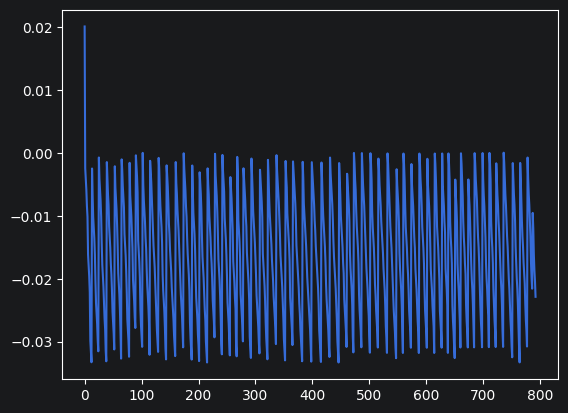

In [20]:
(fig, ax) = plt.subplots()
ax.plot(aux_data_high_ts - aux_data_high_val)

In [29]:
tsync_barcode = tsync_data['Barcode (Scanner)'].astype(int)

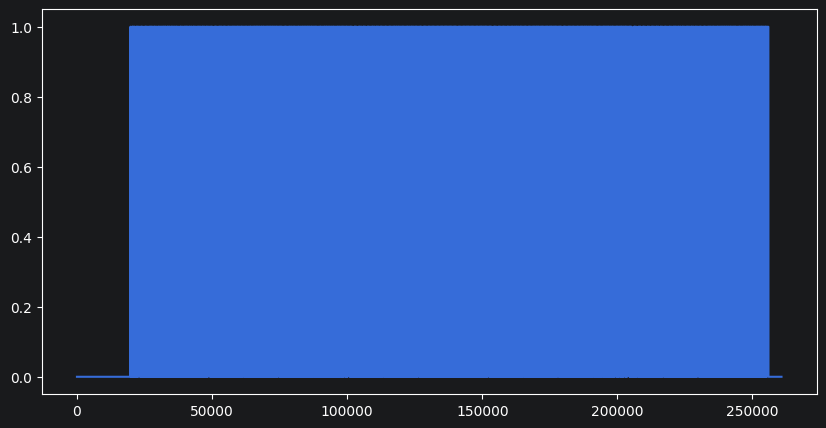

In [31]:
(fig, ax ) = plt.subplots(figsize=(10, 5))
ax.plot(tsync_barcode)
# ax.set_xlim(500, )

In [33]:
tsync_barcode_rising_edge = np.nonzero(np.diff(tsync_barcode) > 0)[0]+1
tsync_barcode_ts = nap.Ts(tsync_time[tsync_barcode_rising_edge], time_units='us')
aux_barcode_ts = nap.Ts(aux_data_high_val, time_units='s')
barcode_group = nap.TsGroup({0: aux_barcode_ts, 1: tsync_barcode_ts})

In [35]:
tsync_barcode_ts

Time (s)
769.996992
770.586992
770.788992
770.990992
771.293992
771.495992
772.202992
...
1003.813992
1004.116992
1004.318992
1004.924992
1005.227992
1005.429992
1005.732992
shape: 798

In [40]:
aux_barcode_ts

Time (s)
-0.020117525
0.56987873
0.77187743
0.973876135
1.276874195
1.478872895
2.18586835
...
232.0604028
232.482400045
232.78539801
233.2903947
233.59339267
233.795391345
234.09838931
shape: 793

In [41]:
crosscorrs = nap.compute_crosscorrelogram(group=barcode_group, time_units = 'ms', windowsize=2000000, binsize = 1 )
shift = crosscorrs.idxmax().iloc[0]

In [42]:
shift

np.float64(770.0180000000003)

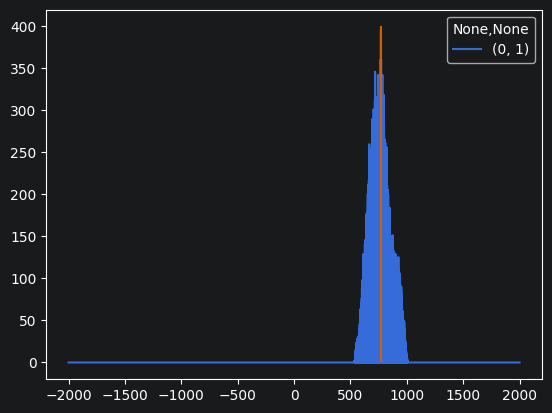

In [48]:
crosscorrs.plot()
ax = plt.gca()
ax.vlines(shift, 0, 400, colors='r')
#ax.set_xlim(22, 23)

In [44]:
np.median(aux_barcode_ts.t+shift-tsync_barcode_ts.t)

ValueError: operands could not be broadcast together with shapes (793,) (798,) 

In [49]:
def closest_match_indices_sorted(A, B, max_tolerance):
    """
    Return one-to-one closest matches between sorted arrays A and B.

    Parameters
    ----------
    A : array-like
        Sorted array of numbers.
    B : array-like
        Sorted array of numbers.
    max_tolerance : float
        Maximum allowed absolute difference for a match.

    Returns
    -------
    matches : dict of np.ndarray
        Dictionary with keys:
            - "A_index"
            - "B_index"
            - "A_value"
            - "B_value"
            - "abs_difference"
            - "difference"

    unmatched_A_indices : np.ndarray
        Indices of elements in A that were not matched.

    unmatched_B_indices : np.ndarray
        Indices of elements in B that were not matched.
    """
    A = np.asarray(A)
    B = np.asarray(B)

    i = 0
    j = 0

    match_A_indices = []
    match_B_indices = []
    match_A_values = []
    match_B_values = []
    match_abs_differences = []
    match_differences = []

    unmatched_A_indices = []
    matched_B_indices = set()

    while i < len(A):
        a = A[i]

        while j < len(B) and B[j] < a - max_tolerance:
            j += 1

        candidates = []

        if j < len(B) and abs(B[j] - a) <= max_tolerance:
            candidates.append(j)

        # j1 = j
        #
        # while j1 < len(B) and B[j1] <= a + max_tolerance:
        #     if abs(B[j1] - a) <= max_tolerance:
        #         candidates.append(j1)
        #     j1 += 1

        if j > 0 and (j - 1) not in matched_B_indices:
            if abs(B[j - 1] - a) <= max_tolerance:
                candidates.append(j - 1)

        candidates = [idx for idx in candidates if idx not in matched_B_indices]

        if candidates:
            best_j = min(candidates, key=lambda idx: abs(B[idx] - a))

            match_A_indices.append(i)
            match_B_indices.append(best_j)
            match_A_values.append(A[i])
            match_B_values.append(B[best_j])
            match_abs_differences.append(abs(B[best_j] - A[i]))
            match_differences.append(B[best_j] - A[i])
            matched_B_indices.add(best_j)

            if best_j == j:
                j += 1
        else:
            unmatched_A_indices.append(i)

        i += 1

    unmatched_B_indices = np.array(
        [idx for idx in range(len(B)) if idx not in matched_B_indices],
        dtype=int,
    )

    matches = {
        "A_index": np.array(match_A_indices, dtype=int),
        "B_index": np.array(match_B_indices, dtype=int),
        "A_value": np.array(match_A_values, dtype=A.dtype),
        "B_value": np.array(match_B_values, dtype=B.dtype),
        "abs_difference": np.array(match_abs_differences),
        "difference": np.array(match_differences),
    }

    matches = pd.DataFrame(matches)

    return matches, np.array(unmatched_A_indices, dtype=int), unmatched_B_indices

In [51]:
matches, unmatched_aux, unmatched_tsync = closest_match_indices_sorted(aux_barcode_ts.t+shift, tsync_barcode_ts.t, max_tolerance=0.025)

In [54]:
matches

,A_index,B_index,A_value,B_value,abs_difference,difference
0,0,0,769.997882,769.996992,0.000890,-0.000890
1,1,1,770.587879,770.586992,0.000887,-0.000887
2,2,2,770.789877,770.788992,0.000885,-0.000885
3,3,3,770.991876,770.990992,0.000884,-0.000884
4,4,4,771.294874,771.293992,0.000882,-0.000882
...,...,...,...,...,...,...
788,788,788,1002.803398,1002.803992,0.000594,0.000594
789,789,789,1003.308395,1003.308992,0.000597,0.000597
790,790,790,1003.611393,1003.611992,0.000599,0.000599
791,791,791,1003.813391,1003.813992,0.000601,0.000601


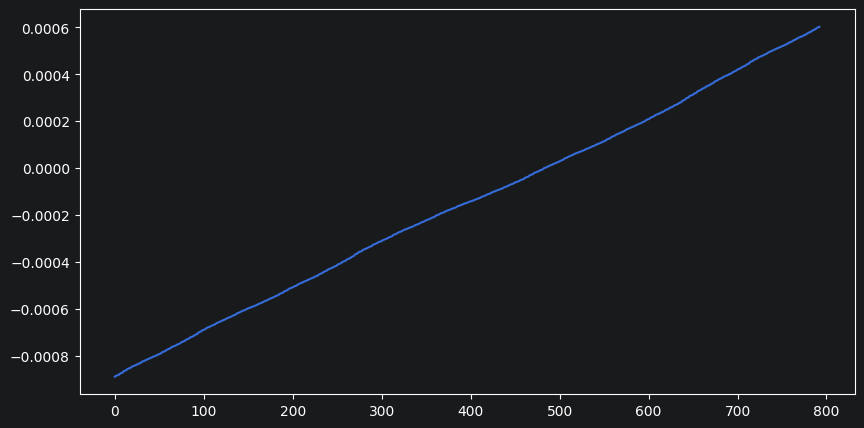

In [52]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(matches['difference'])

In [53]:
print(np.mean(matches['difference'][:100]))
print(np.mean(matches['difference'][-100:]))
print(np.mean(matches['difference']))

-0.0007919333502559311
0.0005051210997430644
-0.00014929128020406155


(794.8, 795.2)

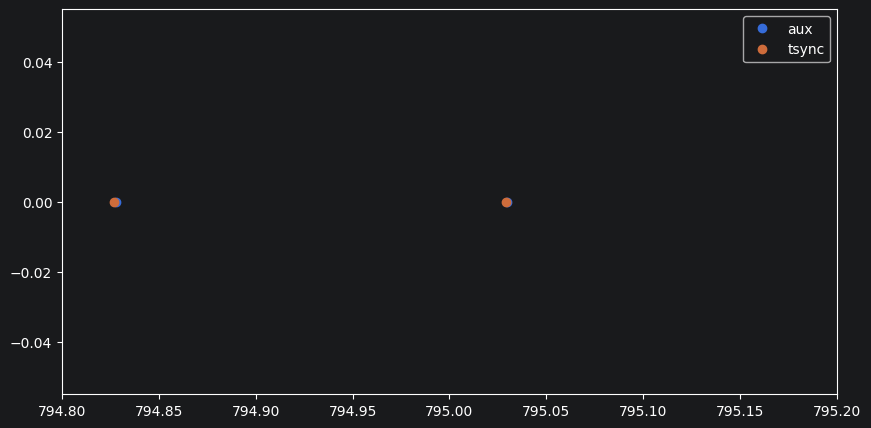

In [57]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(aux_barcode_ts.t+shift, np.zeros_like(aux_barcode_ts.t), 'o', label='aux')
ax.plot(tsync_barcode_ts.fillna(0), 'o', label='tsync')
ax.legend(loc='upper right')
ax.set_xlim(794.8, 795.2)


In [58]:
matches, unmatched_aux, unmatched_tsync = closest_match_indices_sorted(aux_data['ts']+shift, t_frames.t, max_tolerance=0.025)

In [59]:
matches

,A_index,B_index,A_value,B_value,abs_difference,difference
0,0,0,770.018000,770.016992,0.001008,-0.001008
1,1,1,770.051380,770.050992,0.000388,-0.000388
2,2,2,770.084760,770.083992,0.000768,-0.000768
3,3,3,770.118140,770.117992,0.000148,-0.000148
4,4,4,770.151520,770.150992,0.000528,-0.000528
...,...,...,...,...,...,...
7007,7010,7007,1004.060123,1004.060992,0.000869,0.000869
7008,7011,7008,1004.093511,1004.093992,0.000481,0.000481
7009,7012,7009,1004.126900,1004.127992,0.001092,0.001092
7010,7013,7010,1004.160288,1004.160992,0.000704,0.000704


In [60]:
print(matches['B_value'].shape)
print(len(t_frames))
print(len(aux_data['ts']))

(7012,)
7014
7015


In [61]:
unmatched_tsync

array([7012, 7013])

In [62]:
unmatched_aux

array([6955, 6956, 6957])

(794.5, 794.7)

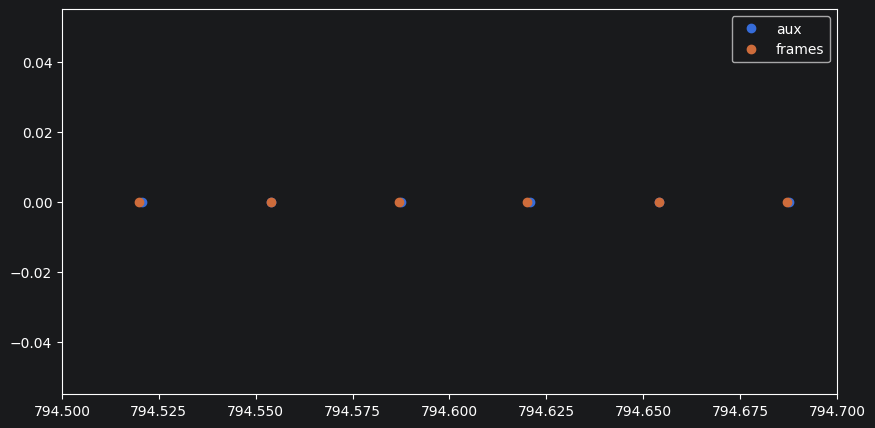

In [64]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(matches['A_value'], np.zeros_like(matches['A_value']),  'o', label='aux')
ax.plot(matches['B_value'], np.zeros_like(matches['B_value']), 'o', label='frames')
ax.legend(loc='upper right')
#ax.set_xlim(2134, 2135)
ax.set_xlim(794.5, 794.7)

(0.0, 5000.0)

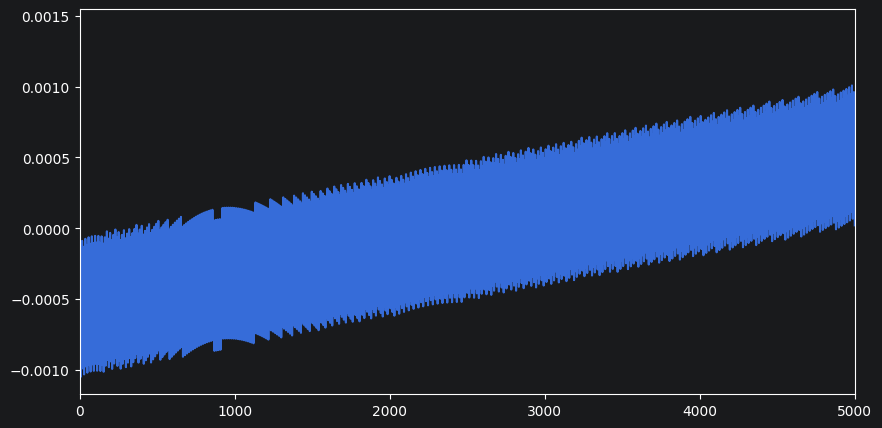

In [65]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(matches['difference'])
ax.set_xlim(0, 5000)

In [66]:
frames_time_idx = nap.Tsd(t = matches['B_value'].to_numpy(),d = matches['A_index'].to_numpy(), time_units='s')

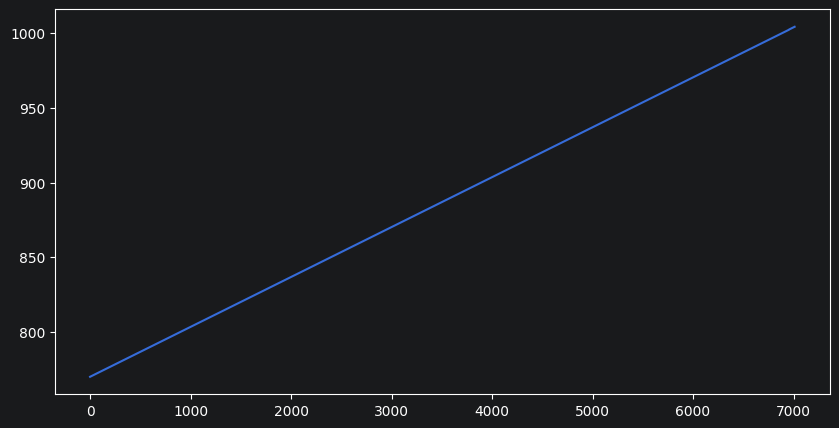

In [67]:
(fig, ax) = plt.subplots(figsize=(10, 5))

ax.plot(frames_time_idx.t)

In [133]:
path_2p = Path(s3d_results_folder)

f_file = path_2p / "F.npy"

In [19]:
cells_f = np.load(f_file, allow_pickle=True)

In [20]:
cells_f

array([[ 856.9276265 ,  782.60226841,  744.14947818, ...,  842.72827797,
         868.64101891,  918.6247989 ],
       [ 600.70937788,  482.95308536,  518.27911683, ...,  740.19263286,
         616.00336653,  542.35673873],
       [ 867.16137886,  662.35052515,  685.16575245, ...,  777.324884  ,
         651.70301868,  729.03523866],
       ...,
       [1003.45493577, 1752.73600208,  672.88276204, ...,  430.28690875,
         876.399709  ,  613.9572311 ],
       [1592.47691958, 1147.03572647, 1455.81812525, ..., 1113.22942371,
        1506.45089346,  546.94094632],
       [1592.42134826, 1118.72660792, 1621.95608213, ...,  474.22297353,
        1268.16032902, 1418.75332338]], shape=(1953, 6013))

In [134]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) > 0)[0]+1